<a href="https://colab.research.google.com/github/Ayush-thakur-01/Ml/blob/main/Assignment_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import zipfile
import requests
import io
import time

from scipy.io import arff
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_selection import chi2
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score
)

In [ ]:
url = "https://archive.ics.uci.edu/static/public/850/raisin.zip"

z = zipfile.ZipFile(io.BytesIO(requests.get(url).content))
z.extractall("/content/raisin")

z2 = zipfile.ZipFile("/content/raisin/Raisin_Dataset.zip")
z2.extractall("/content/raisin/data")

data, meta = arff.loadarff(
    "/content/raisin/data/Raisin_Dataset/Raisin_Dataset.arff"
)

df = pd.DataFrame(data)

print(df.head())
print("Shape:", df.shape)

      Area  MajorAxisLength  MinorAxisLength  Eccentricity  ConvexArea  \
0  87524.0       442.246011       253.291155      0.819738     90546.0   
1  75166.0       406.690687       243.032436      0.801805     78789.0   
2  90856.0       442.267048       266.328318      0.798354     93717.0   
3  45928.0       286.540559       208.760042      0.684989     47336.0   
4  79408.0       352.190770       290.827533      0.564011     81463.0   

     Extent  Perimeter       Class  
0  0.758651   1184.040  b'Kecimen'  
1  0.684130   1121.786  b'Kecimen'  
2  0.637613   1208.575  b'Kecimen'  
3  0.699599    844.162  b'Kecimen'  
4  0.792772   1073.251  b'Kecimen'  
Shape: (900, 8)


In [ ]:
print(df.isnull().sum())

Area               0
MajorAxisLength    0
MinorAxisLength    0
Eccentricity       0
ConvexArea         0
Extent             0
Perimeter          0
Class              0
dtype: int64


In [ ]:
df["Class"] = df["Class"].str.decode("utf-8")

df["Class"] = df["Class"].map({
    "Kecimen": 0,
    "Besni": 1
})

print(df["Class"].value_counts())

Class
0    450
1    450
Name: count, dtype: int64


In [ ]:
X = df.drop("Class", axis=1)
y = df["Class"]

chi_scores, p_values = chi2(X, y)

chi_table = pd.DataFrame({
    "Feature": X.columns,
    "Chi2 Score": chi_scores,
    "P-Value": p_values
}).sort_values("Chi2 Score", ascending=False)

print(chi_table)

           Feature    Chi2 Score   P-Value
4       ConvexArea  6.412753e+06  0.000000
0             Area  6.097822e+06  0.000000
6        Perimeter  2.563142e+04  0.000000
1  MajorAxisLength  1.272952e+04  0.000000
2  MinorAxisLength  2.234351e+03  0.000000
3     Eccentricity  1.804260e+00  0.179198
5           Extent  8.791728e-02  0.766842


In [ ]:
least_important = chi_table.iloc[-1]["Feature"]

X = X.drop(columns=[least_important])

print("Removed feature:", least_important)
print("Remaining features:", list(X.columns))

Removed feature: Extent
Remaining features: ['Area', 'MajorAxisLength', 'MinorAxisLength', 'Eccentricity', 'ConvexArea', 'Perimeter']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (720, 6)
Testing data: (180, 6)


In [ ]:
ada = AdaBoostClassifier(random_state=42)

ada.fit(X_train, y_train)

print("AdaBoost trained successfully!")

AdaBoost trained successfully!


In [ ]:
y_pred_ada = ada.predict(X_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_ada))

print("Accuracy:", accuracy_score(y_test, y_pred_ada))
print("Precision:", precision_score(y_test, y_pred_ada))
print("Recall:", recall_score(y_test, y_pred_ada))

Confusion Matrix:
[[82  8]
 [12 78]]
Accuracy: 0.8888888888888888
Precision: 0.9069767441860465
Recall: 0.8666666666666667


In [ ]:
params = {
    "n_estimators": [50, 100, 200],
    "learning_rate": [0.01, 0.1, 1]
}

grid_ada = GridSearchCV(
    AdaBoostClassifier(random_state=42),
    params,
    cv=5,
    scoring="f1"
)

grid_ada.fit(X_train, y_train)

print("Best Parameters:", grid_ada.best_params_)
print("Best F1-Score:", grid_ada.best_score_)

Best Parameters: {'learning_rate': 1, 'n_estimators': 200}
Best F1-Score: 0.8499906154150016


In [ ]:
best_ada = grid_ada.best_estimator_

y_pred_ada_tuned = best_ada.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_ada_tuned))
print("Precision:", precision_score(y_test, y_pred_ada_tuned))
print("Recall:", recall_score(y_test, y_pred_ada_tuned))
print("F1-Score:", f1_score(y_test, y_pred_ada_tuned))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_ada_tuned))

Accuracy: 0.8611111111111112
Precision: 0.9012345679012346
Recall: 0.8111111111111111
F1-Score: 0.8538011695906432

Confusion Matrix:
[[82  8]
 [17 73]]


In [ ]:
gb = GradientBoostingClassifier(random_state=42)

gb.fit(X_train, y_train)

print("Gradient Boosting trained successfully!")

Gradient Boosting trained successfully!


In [ ]:
y_pred_gb = gb.predict(X_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_gb))

print("Accuracy:", accuracy_score(y_test, y_pred_gb))
print("Precision:", precision_score(y_test, y_pred_gb))
print("Recall:", recall_score(y_test, y_pred_gb))

Confusion Matrix:
[[78 12]
 [14 76]]
Accuracy: 0.8555555555555555
Precision: 0.8636363636363636
Recall: 0.8444444444444444


In [ ]:
params_gb = {
    "n_estimators": [50, 100, 200],
    "learning_rate": [0.01, 0.1, 0.5, 1],
    "max_depth": [3, 4, 5],
    "subsample": [0.8, 1.0]
}

grid_gb = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    params_gb,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_gb.fit(X_train, y_train)

print("Best Parameters:", grid_gb.best_params_)
print("Best F1-Score:", grid_gb.best_score_)

Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
Best F1-Score: 0.8591228070175438


In [ ]:
best_gb = grid_gb.best_estimator_

y_pred_gb_tuned = best_gb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_gb_tuned))
print("Precision:", precision_score(y_test, y_pred_gb_tuned))
print("Recall:", recall_score(y_test, y_pred_gb_tuned))
print("F1-Score:", f1_score(y_test, y_pred_gb_tuned))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_gb_tuned))

Accuracy: 0.8555555555555555
Precision: 0.8809523809523809
Recall: 0.8222222222222222
F1-Score: 0.8505747126436781

Confusion Matrix:
[[80 10]
 [16 74]]


In [ ]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

print("Decision Tree trained successfully!")

Decision Tree trained successfully!


In [ ]:
models = {
    "Decision Tree": dt,
    "AdaBoost": best_ada,
    "Gradient Boosting": best_gb
}

results = []

for name, model in models.items():
    start = time.time()
    model.fit(X_train, y_train)
    training_time = time.time() - start

    pred = model.predict(X_test)

    results.append([
        name,
        accuracy_score(y_test, pred),
        precision_score(y_test, pred),
        recall_score(y_test, pred),
        f1_score(y_test, pred),
        training_time
    ])

comparison = pd.DataFrame(results, columns=[
    "Model", "Accuracy", "Precision",
    "Recall", "F1-Score", "Training Time"
])

print(comparison)

               Model  Accuracy  Precision    Recall  F1-Score  Training Time
0      Decision Tree  0.833333   0.833333  0.833333  0.833333       0.014151
1           AdaBoost  0.861111   0.901235  0.811111  0.853801       1.178771
2  Gradient Boosting  0.855556   0.880952  0.822222  0.850575       2.022470


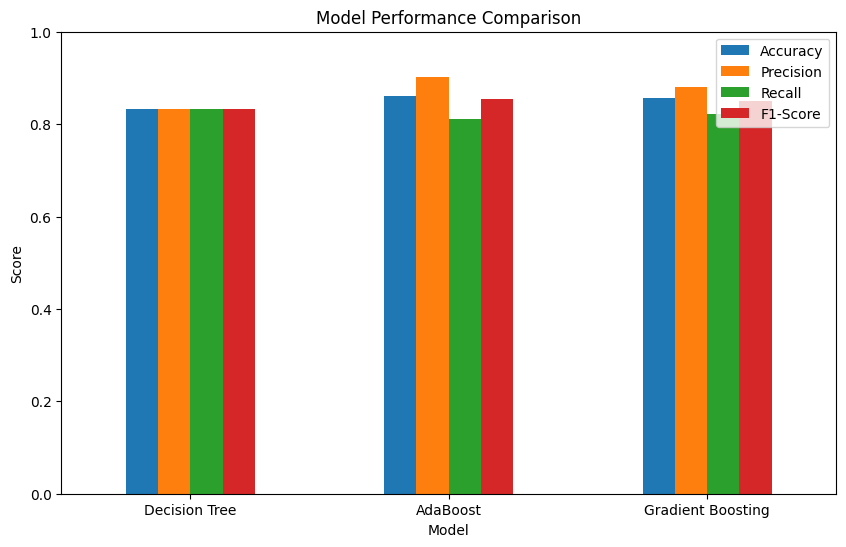

In [ ]:
comparison.set_index("Model")[[
    "Accuracy", "Precision", "Recall", "F1-Score"
]].plot(kind="bar", figsize=(10, 6))

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.show()